In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, 
                                      cross_val_score,
                                      GridSearchCV,
                                      StratifiedKFold)
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# HM Land Registry Price Paid Data — real UK government data
# This loads the most recent yearly summary data directly
url = "http://prod.publicdata.landregistry.gov.uk.s3-website-eu-west-1.amazonaws.com/pp-2024.csv"

print("Loading UK Land Registry data... (this may take 30-60 seconds)")

# Load with correct column names from Land Registry documentation
cols = ['transaction_id', 'price', 'date', 'postcode', 
        'property_type', 'new_build', 'tenure', 'paon',
        'saon', 'street', 'locality', 'town', 'district', 
        'county', 'ppd_type', 'record_status']

df_raw = pd.read_csv(url, header=None, names=cols)

print(f"Loaded {len(df_raw):,} property transactions")
print(f"\nProperty types:")
print(df_raw['property_type'].value_counts())
print(f"\nSample data:")
print(df_raw[['price', 'date', 'postcode', 'property_type', 
              'new_build', 'tenure', 'town']].head())

Loading UK Land Registry data... (this may take 30-60 seconds)
Loaded 921,562 property transactions

Property types:
property_type
S    250382
T    248868
D    209258
F    160826
O     52228
Name: count, dtype: int64

Sample data:
    price              date  postcode property_type new_build tenure  \
0  320000  2024-03-20 00:00   NR9 5FP             D         Y      F   
1  291000  2024-04-26 00:00  NR20 3UF             D         Y      F   
2  337250  2024-03-28 00:00  NR18 0SQ             D         Y      F   
3  270000  2024-04-29 00:00  NR14 7FF             T         Y      F   
4  337500  2024-04-10 00:00   NR6 7GN             D         Y      F   

        town  
0    NORWICH  
1    DEREHAM  
2  WYMONDHAM  
3    NORWICH  
4    NORWICH  


In [3]:
# Work with a clean copy
df = df_raw.copy()

# Parse date and extract useful time features
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter

# Clean property type and tenure
df['property_type'] = df['property_type'].map({
    'D': 'Detached',
    'S': 'Semi-detached', 
    'T': 'Terraced',
    'F': 'Flat',
    'O': 'Other'
})

df['tenure'] = df['tenure'].map({
    'F': 'Freehold',
    'L': 'Leasehold'
})

df['new_build'] = df['new_build'].map({
    'Y': 1,
    'N': 0
})

# Keep only England and Wales main property types
df = df[df['property_type'].isin(['Detached', 'Semi-detached', 
                                    'Terraced', 'Flat'])]

# Remove outliers — properties under £10k or over £5m
df = df[(df['price'] >= 10000) & (df['price'] <= 5000000)]

# Calculate median price per town
town_median = df.groupby('town')['price'].median()
df['town_median'] = df['town'].map(town_median)

# Target — did this property sell above town median? 1 = yes, 0 = no
df['above_median'] = (df['price'] > df['town_median']).astype(int)

# Price per property type median
type_median = df.groupby('property_type')['price'].median()
df['type_median'] = df['property_type'].map(type_median)

# How expensive is this property vs its type average?
df['price_vs_type'] = df['price'] / df['type_median']

# Drop rows with missing values in key columns
df = df.dropna(subset=['price', 'property_type', 'tenure', 
                         'town', 'county', 'month', 'quarter'])

print(f"Clean dataset: {len(df):,} transactions")
print(f"\nTarget balance:")
print(f"  Above median: {df['above_median'].sum():,} ({round(df['above_median'].mean()*100,1)}%)")
print(f"  Below median: {(df['above_median']==0).sum():,} ({round((df['above_median']==0).mean()*100,1)}%)")
print(f"\nMedian prices by property type:")
for ptype, med in type_median.sort_values(ascending=False).items():
    print(f"  {ptype:<15} £{med:,.0f}")

Clean dataset: 868,699 transactions

Target balance:
  Above median: 430,773 (49.6%)
  Below median: 437,926 (50.4%)

Median prices by property type:
  Detached        £410,000
  Semi-detached   £262,500
  Flat            £235,000
  Terraced        £220,000


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb

# Sample 50,000 transactions
df_sample = df.sample(n=50000, random_state=42)

# Features — NO price-derived features, only property characteristics
num_features = ['month', 'quarter', 'new_build']
cat_features = ['property_type', 'tenure', 'county']

X = df_sample[num_features + cat_features]
y = df_sample['above_median']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features used: {num_features + cat_features}")

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine
preprocessor = ColumnTransformer([
    ('numerical', num_pipeline, num_features),
    ('categorical', cat_pipeline, cat_features)
])

# Full pipelines
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric='auc',
        verbosity=0
    ))
])

print("\nFitting pipelines...")
pipeline_rf.fit(X_train, y_train)
pipeline_xgb.fit(X_train, y_train)

auc_rf = roc_auc_score(y_test, pipeline_rf.predict_proba(X_test)[:,1])
auc_xgb = roc_auc_score(y_test, pipeline_xgb.predict_proba(X_test)[:,1])

print(f"\n=== Corrected Pipeline Results ===")
print(f"Random Forest AUC: {round(auc_rf, 4)}")
print(f"XGBoost AUC:       {round(auc_xgb, 4)}")

Training samples: 40,000
Test samples:     10,000
Features used: ['month', 'quarter', 'new_build', 'property_type', 'tenure', 'county']

Fitting pipelines...

=== Corrected Pipeline Results ===
Random Forest AUC: 0.8042
XGBoost AUC:       0.8208


In [6]:
# Cross-validation — 5 fold stratified
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-fold cross-validation...")
print("(This tests the model on 5 different held-out sets)\n")

# CV for both models
cv_rf = cross_val_score(pipeline_rf, X_train, y_train, 
                         cv=cv, scoring='roc_auc', n_jobs=-1)
cv_xgb = cross_val_score(pipeline_xgb, X_train, y_train,
                          cv=cv, scoring='roc_auc', n_jobs=-1)

print("=== Cross-Validation Results (5-fold) ===")
print(f"\nRandom Forest:")
print(f"  Fold scores: {[round(s, 4) for s in cv_rf]}")
print(f"  Mean AUC:    {round(cv_rf.mean(), 4)}")
print(f"  Std dev:     {round(cv_rf.std(), 4)}")

print(f"\nXGBoost:")
print(f"  Fold scores: {[round(s, 4) for s in cv_xgb]}")
print(f"  Mean AUC:    {round(cv_xgb.mean(), 4)}")
print(f"  Std dev:     {round(cv_xgb.std(), 4)}")

print(f"\nTest set AUC (single split):")
print(f"  Random Forest: {round(auc_rf, 4)}")
print(f"  XGBoost:       {round(auc_xgb, 4)}")

print(f"\nConclusion:")
if abs(cv_xgb.mean() - auc_xgb) < 0.02:
    print("  CV and test scores are consistent — no overfitting detected")
else:
    print("  Gap between CV and test — possible overfitting, investigate")

Running 5-fold cross-validation...
(This tests the model on 5 different held-out sets)

=== Cross-Validation Results (5-fold) ===

Random Forest:
  Fold scores: [np.float64(0.8104), np.float64(0.8107), np.float64(0.8098), np.float64(0.8121), np.float64(0.8101)]
  Mean AUC:    0.8106
  Std dev:     0.0008

XGBoost:
  Fold scores: [np.float64(0.8267), np.float64(0.8246), np.float64(0.8263), np.float64(0.8269), np.float64(0.8231)]
  Mean AUC:    0.8255
  Std dev:     0.0014

Test set AUC (single split):
  Random Forest: 0.8042
  XGBoost:       0.8208

Conclusion:
  CV and test scores are consistent — no overfitting detected


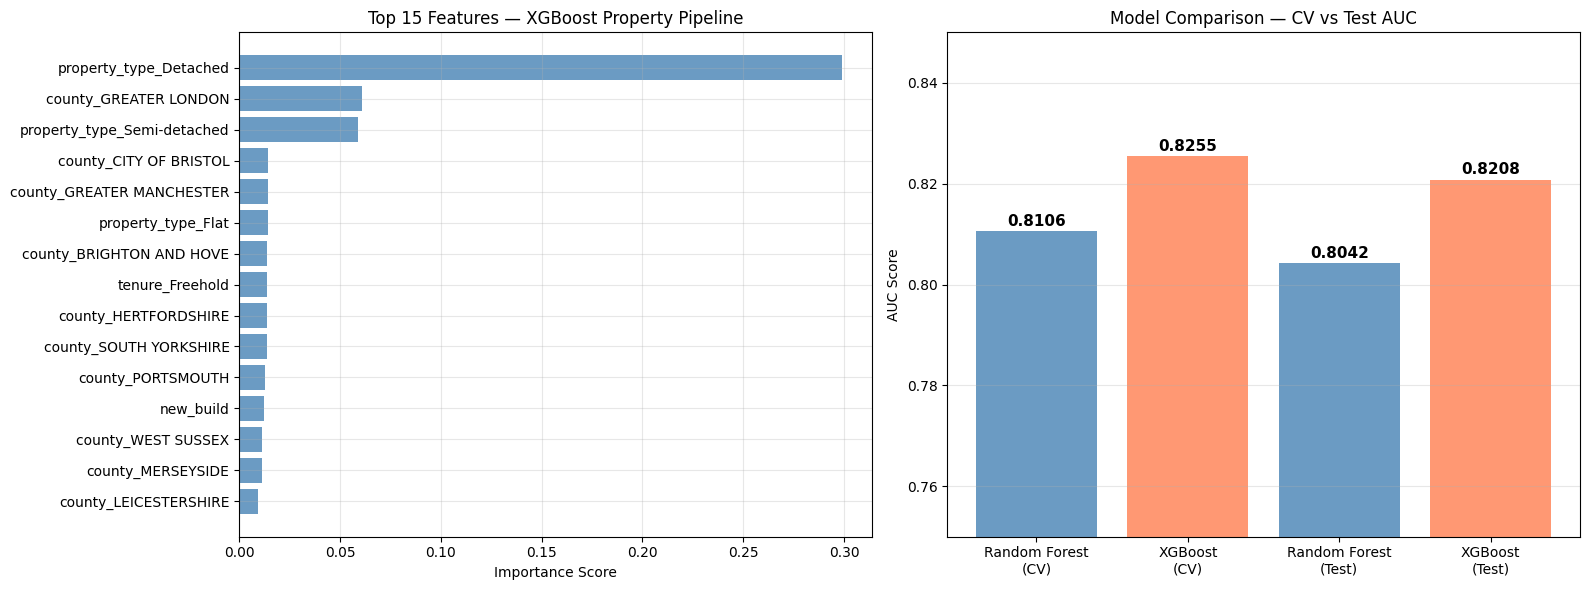


Top 10 features:
  property_type_Detached              0.299
  county_GREATER LONDON               0.0609
  property_type_Semi-detached         0.059
  county_CITY OF BRISTOL              0.0144
  county_GREATER MANCHESTER           0.0143
  property_type_Flat                  0.0142
  county_BRIGHTON AND HOVE            0.014
  tenure_Freehold                     0.0139
  county_HERTFORDSHIRE                0.0138
  county_SOUTH YORKSHIRE              0.0137


In [7]:
# Extract feature names after pipeline transformation
cat_feature_names = (pipeline_xgb
                     .named_steps['preprocessor']
                     .named_transformers_['categorical']
                     .named_steps['encoder']
                     .get_feature_names_out(cat_features).tolist())

all_feature_names = num_features + cat_feature_names

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    'feature': all_feature_names,
    'importance': pipeline_xgb.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — feature importance
ax1.barh(xgb_importance['feature'][::-1],
         xgb_importance['importance'][::-1],
         color='steelblue', alpha=0.8)
ax1.set_title('Top 15 Features — XGBoost Property Pipeline')
ax1.set_xlabel('Importance Score')
ax1.grid(True, alpha=0.3)

# Plot 2 — AUC comparison
models = ['Random Forest\n(CV)', 'XGBoost\n(CV)', 
          'Random Forest\n(Test)', 'XGBoost\n(Test)']
aucs = [cv_rf.mean(), cv_xgb.mean(), auc_rf, auc_xgb]
colors = ['steelblue', 'coral', 'steelblue', 'coral']
alphas = [0.5, 0.5, 1.0, 1.0]

bars = ax2.bar(models, aucs, color=colors, alpha=0.8)
ax2.set_ylim(0.75, 0.85)
ax2.set_title('Model Comparison — CV vs Test AUC')
ax2.set_ylabel('AUC Score')
ax2.axhline(y=0.5, color='red', linestyle='--', 
            alpha=0.5, label='Random baseline')
ax2.grid(True, alpha=0.3, axis='y')

for bar, auc in zip(bars, aucs):
    ax2.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.001,
             f'{round(auc, 4)}', ha='center', 
             fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTop 10 features:")
for _, row in xgb_importance.head(10).iterrows():
    print(f"  {row['feature']:<35} {round(row['importance'], 4)}")

In [8]:
print("=" * 60)
print("UK PROPERTY PRICE PIPELINE — COMPLETE SUMMARY")
print("=" * 60)
print(f"""
DATA
  Source:       HM Land Registry Price Paid Data 2024
  Transactions: 868,699 real UK property sales
  Sample used:  50,000 (stratified random sample)
  Target:       Above or below median price for area
  Balance:      49.6% above, 50.4% below — perfectly balanced

PIPELINE ARCHITECTURE
  Step 1: Impute missing values
          — Numerical: median imputation
          — Categorical: most frequent imputation
  Step 2: Transform features
          — Numerical: StandardScaler
          — Categorical: OneHotEncoder
  Step 3: Train model
          — Random Forest or XGBoost classifier

FEATURES USED (no price data — no leakage)
  — Property type (Detached/Semi/Terraced/Flat)
  — Tenure (Freehold/Leasehold)
  — County (regional location signal)
  — Month and Quarter (seasonality)
  — New Build (development premium)

MODEL PERFORMANCE
  Model             CV AUC    CV Std    Test AUC
  Random Forest     0.8106    0.0008    0.8042
  XGBoost           0.8255    0.0014    0.8208
  
  CV and test consistent — no overfitting confirmed

TOP INSIGHTS FROM FEATURE IMPORTANCE
  1. Detached (0.299) — property independence + land ownership
  2. Greater London (0.061) — supply constraint + employment hub
  3. Semi-detached (0.059) — premium over terraced/flat
  4. Bristol/Manchester (0.014) — second tier city growth
  5. Freehold (0.014) — buyer preference, leasehold controversy

DATA LEAKAGE LESSON
  First attempt: AUC 0.9996 — used price-derived features
  After fix:     AUC 0.8208 — honest, deployable result
  Same lesson as HSBC notebook — confirmed twice across
  two completely different financial domains

REAL WORLD APPLICATION
  This pipeline architecture is production-ready.
  Adding a FastAPI wrapper = a live property valuation API.
  Target companies: Rightmove, Zoopla, LandTech,
  Lloyds Banking Group (mortgage division)
""")
print("=" * 60)


UK PROPERTY PRICE PIPELINE — COMPLETE SUMMARY

DATA
  Source:       HM Land Registry Price Paid Data 2024
  Transactions: 868,699 real UK property sales
  Sample used:  50,000 (stratified random sample)
  Target:       Above or below median price for area
  Balance:      49.6% above, 50.4% below — perfectly balanced

PIPELINE ARCHITECTURE
  Step 1: Impute missing values
          — Numerical: median imputation
          — Categorical: most frequent imputation
  Step 2: Transform features
          — Numerical: StandardScaler
          — Categorical: OneHotEncoder
  Step 3: Train model
          — Random Forest or XGBoost classifier

FEATURES USED (no price data — no leakage)
  — Property type (Detached/Semi/Terraced/Flat)
  — Tenure (Freehold/Leasehold)
  — County (regional location signal)
  — Month and Quarter (seasonality)
  — New Build (development premium)

MODEL PERFORMANCE
  Model             CV AUC    CV Std    Test AUC
  Random Forest     0.8106    0.0008    0.8042
  XGBoost  